In [1]:
from pathlib import Path
import matplotlib.pyplot as plt

import phd_parser as pp

In [2]:
path_drifts = Path(r"C:\Users\jsommer1\OneDrive\02_Projects\[UniZeug]\2024_PhD\01_Project\21_Experiments\01_raw\Box5_Spectrocsopy")
path_experiment = path_drifts / "2026-03-26_SK1002"
path_ir = path_experiment / "omnic" / "01_Reduction"

# path_ir = Path(r"..\\tests\\infrared\\omnic-test-data")

In [3]:
raw = pp.infrared.omnic.read_spa(path_ir, delta_time_seconds=6.7)

print(f"Raw data keys: {raw.keys()}")
print(f"Raw data 'data' keys: {raw['data'].keys()}")
print(f"Raw data 'data' 'x' shape: {raw['data']['x'].shape}")
print(f"Raw data 'data' 'v' shape: {raw['data']['v'].shape}")
print(f"Raw data 'data' 'tos' shape: {raw['data']['tos'].shape}")

print(f"Raw data 'meta' keys: {raw['meta'].keys()}")
print(f"Raw data 'meta' 'xlabel': {raw['meta']['xlabel']}")
print(f"Raw data 'meta' 'xunit': {raw['meta']['xunit']}")
print(f"Raw data 'meta' 'vlabel': {raw['meta']['vlabel']}")
print(f"Raw data 'meta' 'vunit': {raw['meta']['vunit']}")

In [4]:
ir = pp.infrared.IRData.from_omnic_spa(
    path_ir,
    x_label="wavenumber",
    x_2SI_factor=pp.units.SI_FACTORS["wavenumber"]["1/cm"],
    v_label="absorbance",
    v_2SI_factor=1.0,
    )
ir.energy_2SI_factor = pp.units.SI_FACTORS["energy"]["eV"]
ir.frequency_2SI_factor = pp.units.SI_FACTORS["frequency"]["GHz"]
ir.wavelength_2SI_factor = pp.units.SI_FACTORS["length"]["nm"]
ir.sort(ascending=True)

In [5]:
ir.frequency

array([ 11996.40087504,  12010.85437031,  12025.30786559, ...,
       119891.7431045 , 119906.19659978, 119920.65009506], shape=(7468,))

In [6]:
raw["data"]["x"]

array([4000.12231445, 3999.64019775, 3999.15808104, ...,  401.12109377,
        400.63897706,  400.15686035], shape=(7468,))

In [7]:
raw["data"]["v"][0]

array([-0.00778262, -0.00772685, -0.00772423, ...,  6.        ,
        6.        ,  6.        ], shape=(7468,))

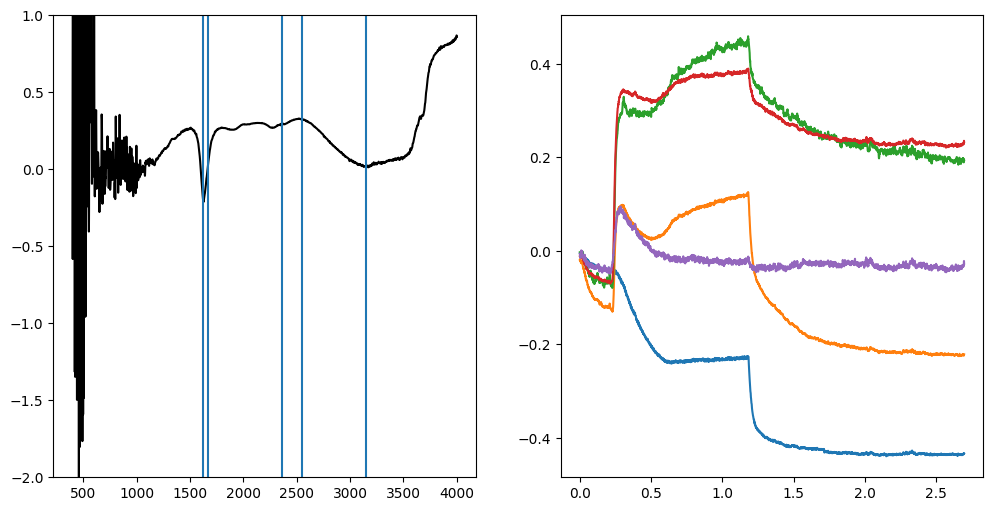

In [ ]:
wavernumbers = [1620, 1670, 2358, 2550, 3150]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

ax0 = axes.ravel()[0]
ax0.set_ylim(-2, 1)
ax1 = axes.ravel()[1]

ax0.plot(ir.wavenumber, ir.values[500], color = "black", label="Last spectrum")


for wn in wavernumbers:
    ax0.axvline(wn)
    
    ax1.plot(ir.tos / 3600, ir.get_evolution(wn))